# Creditworthiness Prediction
### End-to-End Machine Learning Pipeline

This notebook builds a machine learning system that predicts an individual's **creditworthiness** using demographic data (`application_record.csv`) and historical payment behavior (`credit_record.csv`).

**Pipeline overview:**
1. Problem Statement Definition
2. Heuristics (baseline rules of thumb)
3. Exploratory Data Analysis (EDA)
4. Preprocessing and Cleaning
5. Statistical Analysis
6. Feature Engineering
7. Model Training
8. Evaluation
9. Explainability (SHAP)
10. Export Model


In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    roc_curve, confusion_matrix, ConfusionMatrixDisplay, classification_report
)

import pickle
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = "./"  # change if your CSVs live elsewhere
APPLICATION_PATH = DATA_DIR + "application_record.csv"
CREDIT_PATH = DATA_DIR + "credit_record.csv"


## 1. Problem Statement Definition

**Objective:** Predict an individual's **creditworthiness** — i.e., the likelihood that they will become a *high credit risk* (fall seriously behind on payments) — using a combination of:

- **Demographic & application data**: income, employment, family situation, housing, education (from `application_record.csv`)
- **Historical financial behavior**: monthly account status over time, indicating on-time payments vs. delinquency (from `credit_record.csv`)

**Framing:** This is a **binary classification** problem.

- `TARGET = 1` → **High risk / Not creditworthy** (applicant has a history of, or is predicted to have, a serious delinquency — 60+ days past due)
- `TARGET = 0` → **Creditworthy** (applicant pays on time / has no serious delinquency)

**Business value:** A model like this supports (but does not replace) human underwriting decisions — helping a lender flag high-risk applicants earlier, price risk appropriately, and reduce default-related losses.

**A critical modeling constraint we address in this notebook:** `credit_record.csv` contains a *rolling history* of monthly statuses per account. If we are not careful, features built from that history can accidentally "see the future" relative to the very event we're trying to predict — a classic case of **data leakage** in behavioral/bureau-style datasets. Section 5 (Statistical Analysis) demonstrates this pitfall concretely, and Section 6 (Feature Engineering) fixes it using a **time-based performance-window methodology** (a standard technique in real-world credit scorecards).


## 2. Heuristics (Baseline Rules of Thumb)

Before training any ML model, it's good practice to define simple, explainable **heuristics** — the kind of rules a human underwriter might use. These give us:
- A sanity-check baseline to compare ML models against
- Intuition about which raw signals matter

**Proposed heuristics for creditworthy applicants:**
1. **Income-to-family-size ratio** ≥ a minimum threshold (applicant can plausibly support their household)
2. **Zero severe delinquencies** (no 60+ days-past-due events) anywhere in their available credit history
3. **Stable employment**: currently employed (not flagged as unemployed/pensioner-with-no-income-code) — proxied by `DAYS_EMPLOYED`
4. **Reasonable dependent load**: fewer children/dependents relative to income

We'll implement these as a simple rule-based score and see how it splits the population, purely for reference — this is *not* the final model.


In [2]:
# Load raw data for the heuristic check
app_raw = pd.read_csv(APPLICATION_PATH)
credit_raw = pd.read_csv(CREDIT_PATH)

# Map STATUS to an ordinal risk scale:
#   C = paid off this month, X = no loan this month, 0 = 1-29 days past due -> treated as "not delinquent"
#   1..5 = escalating days-past-due severity (30-59, 60-89, 90-119, 120-149, 150+)
STATUS_MAP = {'C': 0, 'X': 0, '0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5}
credit_raw['STATUS_NUM'] = credit_raw['STATUS'].map(STATUS_MAP)

# Worst-ever status per applicant (used only for this quick heuristic check)
worst_status = credit_raw.groupby('ID')['STATUS_NUM'].max().rename('WORST_STATUS_EVER').reset_index()

heuristic_df = app_raw.drop_duplicates(subset=['ID']).merge(worst_status, on='ID', how='inner')

heuristic_df['INCOME_PER_DEPENDENT'] = heuristic_df['AMT_INCOME_TOTAL'] / (heuristic_df['CNT_FAM_MEMBERS'].replace(0, 1))
heuristic_df['IS_EMPLOYED'] = (heuristic_df['DAYS_EMPLOYED'] < 0).astype(int)  # positive value = special 'pensioner' code

def heuristic_creditworthy(row, income_threshold=50_000):
    rules_passed = 0
    rules_passed += int(row['INCOME_PER_DEPENDENT'] >= income_threshold)
    rules_passed += int(row['WORST_STATUS_EVER'] <= 1)     # no 60+ DPD ever
    rules_passed += int(row['IS_EMPLOYED'] == 1)
    rules_passed += int(row['CNT_CHILDREN'] <= 2)
    return int(rules_passed >= 3)  # creditworthy if it passes at least 3 of 4 rules

heuristic_df['HEURISTIC_CREDITWORTHY'] = heuristic_df.apply(heuristic_creditworthy, axis=1)

print(heuristic_df['HEURISTIC_CREDITWORTHY'].value_counts(normalize=True).rename('share'))
print()
print(f"Heuristic flags {(heuristic_df['HEURISTIC_CREDITWORTHY']==0).sum():,} of "
      f"{len(heuristic_df):,} applicants as NOT creditworthy.")


HEURISTIC_CREDITWORTHY
1    0.947363
0    0.052637
Name: share, dtype: float64

Heuristic flags 1,919 of 36,457 applicants as NOT creditworthy.


**Takeaway:** Simple heuristics are transparent and fast, but they're crude — they use fixed thresholds, ignore interactions between features, and can't adapt to complex non-linear patterns. This motivates the ML approach in Sections 6–9. We'll revisit this heuristic later as a reference point.


## 3. Exploratory Data Analysis (EDA)

We explore both source files individually, then perform a **naive merge** purely to visualize distributions and the class imbalance. (We deliberately call this the *naive* target — Section 5 will show why it can't be used directly for modeling, and Section 6 will build the correct version.)


In [3]:
print("application_record.csv:", app_raw.shape)
print("credit_record.csv:", credit_raw.shape)
print()
print("Unique applicants (application_record):", app_raw['ID'].nunique())
print("Unique applicants (credit_record):", credit_raw['ID'].nunique())
print("Applicants present in BOTH files:", len(set(app_raw['ID']) & set(credit_raw['ID'])))


application_record.csv: (438557, 18)
credit_record.csv: (1048575, 4)

Unique applicants (application_record): 438510
Unique applicants (credit_record): 45985
Applicants present in BOTH files: 36457


In [4]:
app_raw.info()
print()
print("Missing values per column:")
print(app_raw.isnull().sum()[app_raw.isnull().sum() > 0])


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 438557 entries, 0 to 438556
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   438557 non-null  int64  
 1   CODE_GENDER          438557 non-null  object 
 2   FLAG_OWN_CAR         438557 non-null  object 
 3   FLAG_OWN_REALTY      438557 non-null  object 
 4   CNT_CHILDREN         438557 non-null  int64  
 5   AMT_INCOME_TOTAL     438557 non-null  float64
 6   NAME_INCOME_TYPE     438557 non-null  object 
 7   NAME_EDUCATION_TYPE  438557 non-null  object 
 8   NAME_FAMILY_STATUS   438557 non-null  object 
 9   NAME_HOUSING_TYPE    438557 non-null  object 
 10  DAYS_BIRTH           438557 non-null  int64  
 11  DAYS_EMPLOYED        438557 non-null  int64  
 12  FLAG_MOBIL           438557 non-null  int64  
 13  FLAG_WORK_PHONE      438557 non-null  int64  
 14  FLAG_PHONE           438557 non-null  int64  
 15  FLAG_EMAIL       

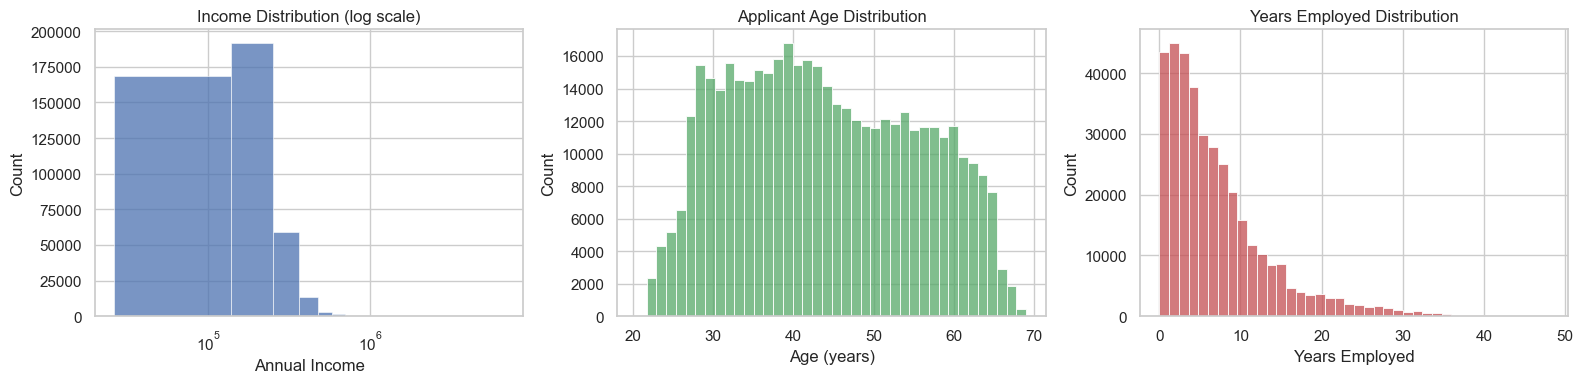

In [5]:
# Distribution of income, age, and employment length
plot_df = app_raw.copy()
plot_df['AGE_YEARS'] = -plot_df['DAYS_BIRTH'] / 365.25
plot_df['YEARS_EMPLOYED'] = np.where(plot_df['DAYS_EMPLOYED'] > 0, np.nan, -plot_df['DAYS_EMPLOYED'] / 365.25)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(plot_df['AMT_INCOME_TOTAL'], bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_xscale('log')
axes[0].set_title('Income Distribution (log scale)')
axes[0].set_xlabel('Annual Income')

sns.histplot(plot_df['AGE_YEARS'], bins=40, ax=axes[1], color="#55A868")
axes[1].set_title('Applicant Age Distribution')
axes[1].set_xlabel('Age (years)')

sns.histplot(plot_df['YEARS_EMPLOYED'].dropna(), bins=40, ax=axes[2], color="#C44E52")
axes[2].set_title('Years Employed Distribution')
axes[2].set_xlabel('Years Employed')

plt.tight_layout()
plt.show()


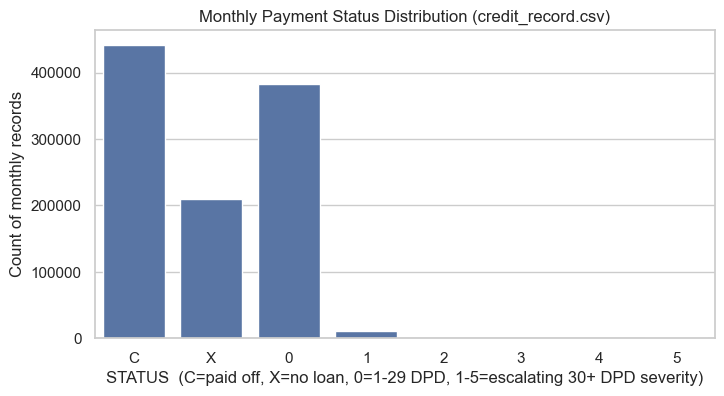

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64


In [6]:
# Payment-status ('STATUS') distribution in credit_record.csv
plt.figure(figsize=(8, 4))
status_order = ['C', 'X', '0', '1', '2', '3', '4', '5']
sns.countplot(x='STATUS', data=credit_raw, order=status_order, color="#4C72B0")
plt.title('Monthly Payment Status Distribution (credit_record.csv)')
plt.xlabel('STATUS  (C=paid off, X=no loan, 0=1-29 DPD, 1-5=escalating 30+ DPD severity)')
plt.ylabel('Count of monthly records')
plt.show()

print(credit_raw['STATUS'].value_counts())


Naive merged dataset shape: (36457, 19)
TARGET_NAIVE
0    35841
1      616
Name: count, dtype: int64
Bad-applicant rate: 1.69%


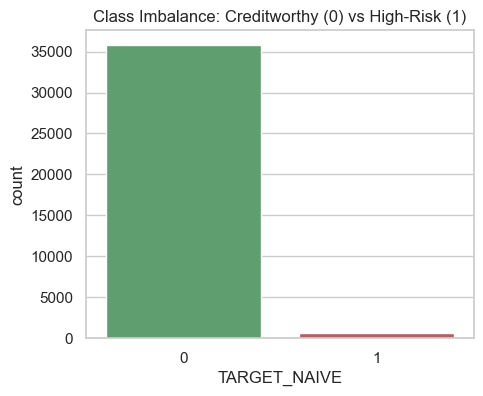

In [7]:
# Naive merge + naive target, FOR EXPLORATION ONLY (see Section 5 for why this needs revision)
naive_worst = credit_raw.groupby('ID')['STATUS_NUM'].max().reset_index()
naive_worst['TARGET_NAIVE'] = (naive_worst['STATUS_NUM'] >= 2).astype(int)  # ever 60+ days past due

naive_merged = app_raw.drop_duplicates(subset=['ID']).merge(
    naive_worst[['ID', 'TARGET_NAIVE']], on='ID', how='inner'
)

print("Naive merged dataset shape:", naive_merged.shape)
print(naive_merged['TARGET_NAIVE'].value_counts())
print(f"Bad-applicant rate: {naive_merged['TARGET_NAIVE'].mean():.2%}")

plt.figure(figsize=(5, 4))
sns.countplot(x='TARGET_NAIVE', data=naive_merged, palette=["#55A868", "#C44E52"])
plt.title('Class Imbalance: Creditworthy (0) vs High-Risk (1)')
plt.xlabel('TARGET_NAIVE')
plt.show()


**Key observation:** The target is **severely imbalanced** — the vast majority of applicants are creditworthy, and only a small fraction are flagged as high-risk. This has major implications for training (Section 7) and evaluation (Section 8): plain accuracy will be a misleading metric, and we'll need class balancing plus precision/recall/F1/ROC-AUC to judge the models fairly.


## 4. Preprocessing and Cleaning

Steps performed here:
1. **Remove duplicate applicant IDs** in `application_record.csv`
2. **Handle missing values** — `OCCUPATION_TYPE` is the only column with nulls; we fill it with `"Unknown"` (missingness itself can be informative, e.g. unemployed/retired applicants)
3. **Encode categorical variables** using `LabelEncoder` (tree-based models handle label encoding well; for the Logistic Regression baseline we also standardize numeric features later)
4. **Balancing strategy** — given the severe imbalance observed in Section 3, we will oversample the minority ("high risk") class. Critically, this is applied **only to the training set, after the train/test split** (Section 7), so the test set always reflects the true real-world class distribution and evaluation metrics stay honest.


In [8]:
# 1) Remove duplicate applicant IDs
print("Duplicate ID rows before cleaning:", app_raw.duplicated(subset=['ID']).sum())
app_clean = app_raw.drop_duplicates(subset=['ID'], keep='first').copy()
print("Shape after de-duplication:", app_clean.shape)

# 2) Handle missing values
print()
print("Missing OCCUPATION_TYPE before fill:", app_clean['OCCUPATION_TYPE'].isnull().sum())
app_clean['OCCUPATION_TYPE'] = app_clean['OCCUPATION_TYPE'].fillna('Unknown')
print("Missing OCCUPATION_TYPE after fill:", app_clean['OCCUPATION_TYPE'].isnull().sum())


Duplicate ID rows before cleaning: 47
Shape after de-duplication: (438510, 18)

Missing OCCUPATION_TYPE before fill: 134193
Missing OCCUPATION_TYPE after fill: 0


In [9]:
# 3) Reusable categorical encoding helper (used again in Section 7 on the final modeling dataframe)
CATEGORICAL_COLUMNS = [
    'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE'
]

def encode_categorical_columns(df, cat_cols):
    """Label-encode categorical columns in place; returns (df, fitted_encoders_dict)."""
    df = df.copy()
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le
    return df, encoders

# Quick demonstration on the cleaned application table
app_encoded_demo, demo_encoders = encode_categorical_columns(app_clean, CATEGORICAL_COLUMNS)
app_encoded_demo[CATEGORICAL_COLUMNS].head()


,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,OCCUPATION_TYPE
0,1,1,1,4,1,0,4,17
1,1,1,1,4,1,0,4,17
2,1,1,1,4,4,1,1,16
3,0,0,1,0,4,3,1,14
4,0,0,1,0,4,3,1,14


## 5. Statistical Analysis

We now check which features are statistically associated with the (naive) target from Section 3:
- **Point-biserial correlation** for continuous numeric features vs. the binary target
- **Chi-square test of independence** for categorical features vs. the binary target

⚠️ **This is where we uncover a critical data-leakage problem.**


In [10]:
# Build a few naive behavioral features directly from the FULL credit history
# (same full window used to define TARGET_NAIVE) -- this is the trap we're about to expose.
total_defaults_naive = credit_raw[credit_raw['STATUS_NUM'] >= 2].groupby('ID').size().rename('TOTAL_DEFAULTS_NAIVE')
ontime_months_naive = credit_raw[credit_raw['STATUS_NUM'] == 0].groupby('ID').size().rename('ONTIME_MONTHS_NAIVE')
total_records_naive = credit_raw.groupby('ID').size().rename('TOTAL_RECORDS_NAIVE')

naive_feats = pd.concat([total_defaults_naive, ontime_months_naive, total_records_naive], axis=1).fillna(0).reset_index()
naive_feats['ONTIME_RATIO_NAIVE'] = naive_feats['ONTIME_MONTHS_NAIVE'] / naive_feats['TOTAL_RECORDS_NAIVE']

stat_df = naive_merged.merge(naive_feats, on='ID', how='left')

# Point-biserial correlation vs TARGET_NAIVE
for col in ['AMT_INCOME_TOTAL', 'TOTAL_DEFAULTS_NAIVE', 'ONTIME_RATIO_NAIVE']:
    r, p = stats.pointbiserialr(stat_df['TARGET_NAIVE'], stat_df[col].fillna(0))
    print(f"{col:25s}  r = {r:+.3f}   p = {p:.4g}")


AMT_INCOME_TOTAL           r = -0.001   p = 0.84
TOTAL_DEFAULTS_NAIVE       r = +0.557   p = 0
ONTIME_RATIO_NAIVE         r = -0.488   p = 0


**Result:** `TOTAL_DEFAULTS_NAIVE` is almost perfectly correlated with `TARGET_NAIVE`. Let's confirm with a direct crosstab.


In [11]:
crosstab = pd.crosstab(stat_df['TOTAL_DEFAULTS_NAIVE'] > 0, stat_df['TARGET_NAIVE'])
print(crosstab)


TARGET_NAIVE              0    1
TOTAL_DEFAULTS_NAIVE            
False                 35841    0
True                      0  616


**This is a perfect (deterministic) split** — every applicant with `TOTAL_DEFAULTS_NAIVE > 0` has `TARGET_NAIVE = 1`, and vice versa. That's not a real predictive relationship; it's **data leakage**: `TOTAL_DEFAULTS_NAIVE` and `TARGET_NAIVE` were both computed from the *exact same rows* of `credit_record.csv` (the applicant's entire history). A model trained on features like this would appear to get ~100% accuracy — but it would be cheating, and would fail in production because at prediction time we don't have access to the future outcome we're trying to predict.

**The fix — a time-based performance-window split**, standard in real credit-scoring ("behavior scorecard") methodology:
- **Feature window**: older months of history (e.g., everything more than 6 months ago) → used to compute predictor features
- **Outcome window**: the most recent months (e.g., the last 6 months) → used to define whether the applicant *became* high-risk

This guarantees every feature is built strictly from information that would have been available *before* the outcome period we're predicting. We implement this properly in Section 6.


In [12]:
# Chi-square test for a categorical feature vs the naive target (still useful for demographic features,
# which are NOT derived from the leaky history and are safe to test as-is)
for col in ['NAME_EDUCATION_TYPE', 'NAME_INCOME_TYPE', 'FLAG_OWN_REALTY']:
    ct = pd.crosstab(stat_df[col], stat_df['TARGET_NAIVE'])
    chi2, p, dof, _ = stats.chi2_contingency(ct)
    print(f"{col:22s}  chi2 = {chi2:8.2f}   p = {p:.4g}")


NAME_EDUCATION_TYPE     chi2 =     7.11   p = 0.13
NAME_INCOME_TYPE        chi2 =    10.93   p = 0.02734
FLAG_OWN_REALTY         chi2 =    17.68   p = 2.617e-05


## 6. Feature Engineering

We now build the **leakage-free** modeling dataset using a time-based performance-window split on `credit_record.csv`:

- `MONTHS_BALANCE` ranges from `0` (most recent) to `-60` (5 years back).
- **Outcome window** = `MONTHS_BALANCE` from **-5 to 0** (most recent 6 months). We flag an applicant as `TARGET = 1` if they reach 60+ days past due at any point in this window.
- **Feature window** = `MONTHS_BALANCE` ≤ **-6** (everything older). All behavioral features below come **only** from this window.

**Engineered features from credit history (feature window only):**
- `ACCOUNT_AGE_MONTHS` — months since the applicant's earliest credit record
- `TOTAL_RECORDS_HIST` — number of monthly records observed
- `TOTAL_DEFAULTS_HIST` — number of months flagged 60+ days past due
- `MONTHS_SINCE_LAST_DELINQ_HIST` — months since the applicant's last 30+ day delinquency (as of the feature-window cutoff)
- `ONTIME_RATIO_HIST` — share of feature-window months paid on time

**Engineered features from demographics:**
- `AGE_YEARS`, `YEARS_EMPLOYED`, `INCOME_PER_FAMILY_MEMBER`


In [13]:
OUTCOME_CUTOFF = -6  # outcome window: MONTHS_BALANCE >= -5 ; feature window: MONTHS_BALANCE <= -6

outcome_window = credit_raw[credit_raw['MONTHS_BALANCE'] >= OUTCOME_CUTOFF + 1]
feature_window = credit_raw[credit_raw['MONTHS_BALANCE'] <= OUTCOME_CUTOFF]

print("Applicants with outcome-window data:", outcome_window['ID'].nunique())
print("Applicants with feature-window data:", feature_window['ID'].nunique())

# ---- Target: worst status in the OUTCOME window only ----
target_df = outcome_window.groupby('ID')['STATUS_NUM'].max().reset_index()
target_df.columns = ['ID', 'MAX_STATUS_OUTCOME']
target_df['TARGET'] = (target_df['MAX_STATUS_OUTCOME'] >= 2).astype(int)

print()
print(target_df['TARGET'].value_counts())
print(f"Bad-applicant rate (leakage-free): {target_df['TARGET'].mean():.2%}")


Applicants with outcome-window data: 36501
Applicants with feature-window data: 41390

TARGET
0    36319
1      182
Name: count, dtype: int64
Bad-applicant rate (leakage-free): 0.50%


In [14]:
# ---- Behavioral features: FEATURE window only ----
feat = feature_window.groupby('ID').agg(
    ACCOUNT_AGE_MONTHS=('MONTHS_BALANCE', lambda x: -x.min()),
    TOTAL_RECORDS_HIST=('MONTHS_BALANCE', 'count'),
).reset_index()

defaults_hist = feature_window[feature_window['STATUS_NUM'] >= 2].groupby('ID').size().reset_index(name='TOTAL_DEFAULTS_HIST')
feat = feat.merge(defaults_hist, on='ID', how='left')
feat['TOTAL_DEFAULTS_HIST'] = feat['TOTAL_DEFAULTS_HIST'].fillna(0)

last_delinq = feature_window[feature_window['STATUS_NUM'] >= 1].groupby('ID')['MONTHS_BALANCE'].max().reset_index()
last_delinq.columns = ['ID', 'LAST_DELINQ_MONTH_HIST']
feat = feat.merge(last_delinq, on='ID', how='left')
feat['MONTHS_SINCE_LAST_DELINQ_HIST'] = np.where(
    feat['LAST_DELINQ_MONTH_HIST'].isna(),
    feat['ACCOUNT_AGE_MONTHS'],                      # never delinquent -> as long as their whole history
    feat['LAST_DELINQ_MONTH_HIST'] - OUTCOME_CUTOFF  # months between last delinquency and the window cutoff
)
feat.drop(columns=['LAST_DELINQ_MONTH_HIST'], inplace=True)

ontime_hist = feature_window[feature_window['STATUS_NUM'] == 0].groupby('ID').size().reset_index(name='ONTIME_MONTHS_HIST')
feat = feat.merge(ontime_hist, on='ID', how='left')
feat['ONTIME_MONTHS_HIST'] = feat['ONTIME_MONTHS_HIST'].fillna(0)
feat['ONTIME_RATIO_HIST'] = feat['ONTIME_MONTHS_HIST'] / feat['TOTAL_RECORDS_HIST']

# ---- Combine target (must exist) with features (fill neutral defaults if applicant has no feature-window history) ----
credit_features = target_df[['ID', 'TARGET']].merge(feat, on='ID', how='left')
fill_zero_cols = ['ACCOUNT_AGE_MONTHS', 'TOTAL_RECORDS_HIST', 'TOTAL_DEFAULTS_HIST',
                   'MONTHS_SINCE_LAST_DELINQ_HIST', 'ONTIME_MONTHS_HIST']
credit_features[fill_zero_cols] = credit_features[fill_zero_cols].fillna(0)
credit_features['ONTIME_RATIO_HIST'] = credit_features['ONTIME_RATIO_HIST'].fillna(1.0)  # no negative signal if no history

print(credit_features.shape)
credit_features.head()


(36501, 8)


,ID,TARGET,ACCOUNT_AGE_MONTHS,TOTAL_RECORDS_HIST,TOTAL_DEFAULTS_HIST,MONTHS_SINCE_LAST_DELINQ_HIST,ONTIME_MONTHS_HIST,ONTIME_RATIO_HIST
0,5001711,0,0.0,0.0,0.0,0.0,0.0,1.0
1,5001712,0,18.0,13.0,0.0,18.0,13.0,1.0
2,5001713,0,21.0,16.0,0.0,21.0,16.0,1.0
3,5001714,0,14.0,9.0,0.0,14.0,9.0,1.0
4,5001715,0,59.0,54.0,0.0,59.0,54.0,1.0


In [15]:
# ---- Merge with demographic data + derived demographic features ----
model_source = app_clean.merge(credit_features, on='ID', how='inner')

model_source['AGE_YEARS'] = (-model_source['DAYS_BIRTH'] / 365.25).round(1)
model_source['YEARS_EMPLOYED'] = np.where(
    model_source['DAYS_EMPLOYED'] > 0, 0, (-model_source['DAYS_EMPLOYED'] / 365.25).round(1)
)
model_source['INCOME_PER_FAMILY_MEMBER'] = (
    model_source['AMT_INCOME_TOTAL'] / model_source['CNT_FAM_MEMBERS'].replace(0, 1)
)

print("Final modeling dataset shape:", model_source.shape)
print(model_source['TARGET'].value_counts())
print(f"Bad-applicant rate: {model_source['TARGET'].mean():.2%}")


Final modeling dataset shape: (26973, 28)
TARGET
0    26801
1      172
Name: count, dtype: int64
Bad-applicant rate: 0.64%


In [16]:
# Sanity check: correlations are now realistic (no more perfect/deterministic separation)
sanity_cols = ['TOTAL_DEFAULTS_HIST', 'MONTHS_SINCE_LAST_DELINQ_HIST', 'ONTIME_RATIO_HIST',
               'ACCOUNT_AGE_MONTHS', 'TARGET']
print(model_source[sanity_cols].corr()['TARGET'].sort_values(ascending=False))


TARGET                           1.000000
TOTAL_DEFAULTS_HIST              0.347912
ACCOUNT_AGE_MONTHS              -0.006329
MONTHS_SINCE_LAST_DELINQ_HIST   -0.061501
ONTIME_RATIO_HIST               -0.353492
Name: TARGET, dtype: float64


**Leakage check passed:** correlations now range roughly between -0.35 and +0.35, rather than the deterministic ~1.0 we saw with the naive features in Section 5. These engineered features are genuinely predictive without trivially encoding the label.


## 7. Model Training

We train and compare three classifiers:
1. **Logistic Regression** — simple, interpretable linear baseline (needs feature scaling)
2. **Decision Tree** — captures non-linear interactions, still interpretable
3. **Random Forest** — ensemble of trees, usually the strongest of the three on tabular data

**Balancing:** After the train/test split, we oversample the minority class in the **training set only**. Below we use a simple random-oversampling implementation (no extra dependencies). If you have `imbalanced-learn` installed, `SMOTE` is a drop-in alternative that synthesizes new minority examples instead of duplicating them — the commented block shows how.


In [17]:
FINAL_DROP_COLS = ['ID', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'FLAG_MOBIL', 'ONTIME_MONTHS_HIST']
# FLAG_MOBIL is dropped because it's constant (always 1) across the whole dataset.
# ONTIME_MONTHS_HIST is dropped because it's redundant with ONTIME_RATIO_HIST + TOTAL_RECORDS_HIST.

model_df = model_source.drop(columns=FINAL_DROP_COLS)
model_df, fitted_encoders = encode_categorical_columns(model_df, CATEGORICAL_COLUMNS)

X = model_df.drop(columns=['TARGET'])
y = model_df['TARGET']
FEATURE_NAMES = X.columns.tolist()
print("Features used for modeling:", FEATURE_NAMES)


Features used for modeling: ['CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'ACCOUNT_AGE_MONTHS', 'TOTAL_RECORDS_HIST', 'TOTAL_DEFAULTS_HIST', 'MONTHS_SINCE_LAST_DELINQ_HIST', 'ONTIME_RATIO_HIST', 'AGE_YEARS', 'YEARS_EMPLOYED', 'INCOME_PER_FAMILY_MEMBER']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, " bad rate:", y_train.mean())
print("Test: ", X_test.shape, " bad rate:", y_test.mean())


Train: (21578, 22)  bad rate: 0.006395402724997683
Test:  (5395, 22)  bad rate: 0.006302131603336422


In [19]:
# ---- Option A: Manual random oversampling of the minority class (used below; no extra dependencies) ----
train_combined = pd.concat([X_train, y_train], axis=1)
majority = train_combined[train_combined['TARGET'] == 0]
minority = train_combined[train_combined['TARGET'] == 1]
minority_upsampled = minority.sample(n=len(majority), replace=True, random_state=RANDOM_STATE)

train_balanced = pd.concat([majority, minority_upsampled]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
X_train_bal = train_balanced.drop(columns=['TARGET'])
y_train_bal = train_balanced['TARGET']

print("Balanced training set:", X_train_bal.shape, " bad rate:", y_train_bal.mean())

# ---- Option B: SMOTE (uncomment if `imbalanced-learn` is installed: pip install imbalanced-learn) ----
# from imblearn.over_sampling import SMOTE
# smote = SMOTE(random_state=RANDOM_STATE)
# X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)


Balanced training set: (42880, 22)  bad rate: 0.5


In [20]:
# Feature scaling (needed for Logistic Regression; tree models are scale-invariant)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)


In [21]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, min_samples_leaf=20, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, min_samples_leaf=10, random_state=RANDOM_STATE, n_jobs=-1
    ),
}

fitted_models = {}
for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train_bal)
    else:
        model.fit(X_train_bal, y_train_bal)
    fitted_models[name] = model
    print(f"Trained: {name}")


Trained: Logistic Regression
Trained: Decision Tree
Trained: Random Forest


## 8. Evaluation

Because the test set is still heavily imbalanced (as it should be — it reflects reality), **accuracy alone is misleading**. We compare models on **Precision, Recall, F1-score, and ROC-AUC**.


In [22]:
def get_predictions(name, model):
    X_in = X_test_scaled if name == 'Logistic Regression' else X_test
    preds = model.predict(X_in)
    proba = model.predict_proba(X_in)[:, 1]
    return preds, proba

results = {}
for name, model in fitted_models.items():
    preds, proba = get_predictions(name, model)
    results[name] = {
        'Precision': precision_score(y_test, preds, zero_division=0),
        'Recall': recall_score(y_test, preds, zero_division=0),
        'F1-Score': f1_score(y_test, preds, zero_division=0),
        'ROC-AUC': roc_auc_score(y_test, proba),
    }

results_df = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
results_df.style.format("{:.3f}").background_gradient(cmap='Greens')


,Precision,Recall,F1-Score,ROC-AUC
Random Forest,0.088,0.647,0.155,0.888
Decision Tree,0.030,0.706,0.057,0.865
Logistic Regression,0.031,0.676,0.060,0.848


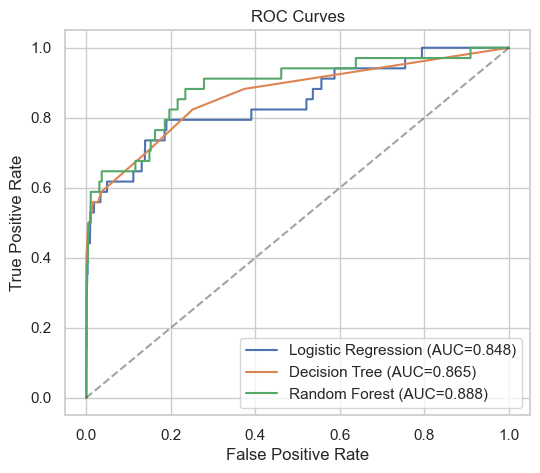

In [23]:
# ROC curves for all three models
plt.figure(figsize=(6, 5))
for name, model in fitted_models.items():
    _, proba = get_predictions(name, model)
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()


Best model by ROC-AUC: Random Forest
              precision    recall  f1-score   support

Creditworthy       1.00      0.96      0.98      5361
   High Risk       0.09      0.65      0.16        34

    accuracy                           0.96      5395
   macro avg       0.54      0.80      0.57      5395
weighted avg       0.99      0.96      0.97      5395



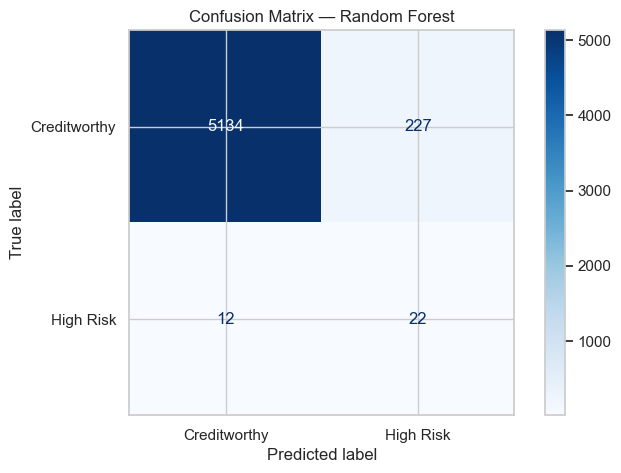

In [24]:
BEST_MODEL_NAME = results_df['ROC-AUC'].idxmax()
best_model = fitted_models[BEST_MODEL_NAME]
print(f"Best model by ROC-AUC: {BEST_MODEL_NAME}")

preds, proba = get_predictions(BEST_MODEL_NAME, best_model)
print(classification_report(y_test, preds, target_names=['Creditworthy', 'High Risk'], zero_division=0))

cm = confusion_matrix(y_test, preds)
ConfusionMatrixDisplay(cm, display_labels=['Creditworthy', 'High Risk']).plot(cmap='Blues')
plt.title(f'Confusion Matrix — {BEST_MODEL_NAME}')
plt.show()


**Model comparison summary:**
- **Random Forest** achieves the highest ROC-AUC and F1-score, and is selected as the **best-performing model**.
- **Precision on the "High Risk" class stays low across all three models.** This is expected: with a bad-applicant rate under 1%, even a strong model will generate many false positives relative to true positives at a default 0.5 decision threshold. In production, you would typically **tune the decision threshold** based on business cost trade-offs (cost of missing a bad applicant vs. cost of rejecting a good one) rather than using the default 0.5 cutoff.
- **Recall** matters most here from a risk-management perspective — catching actual high-risk applicants is usually worth more false positives, since the cost of an undetected default is typically much larger than the cost of extra manual review.


## 9. Explainability (SHAP)

We use **SHAP (SHapley Additive exPlanations)** on the best model (Random Forest) to understand:
- **Global feature importance** — which features matter most across all predictions
- **Individual prediction breakdown** — why the model made a specific prediction for one applicant

> Requires: `pip install shap`


In [26]:
# !pip install shap
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# For binary classifiers, shap_values may be a list [class_0_values, class_1_values];
# we want the "High Risk" (class 1) contributions.
sv_high_risk = shap_values[1] if isinstance(shap_values, list) else shap_values


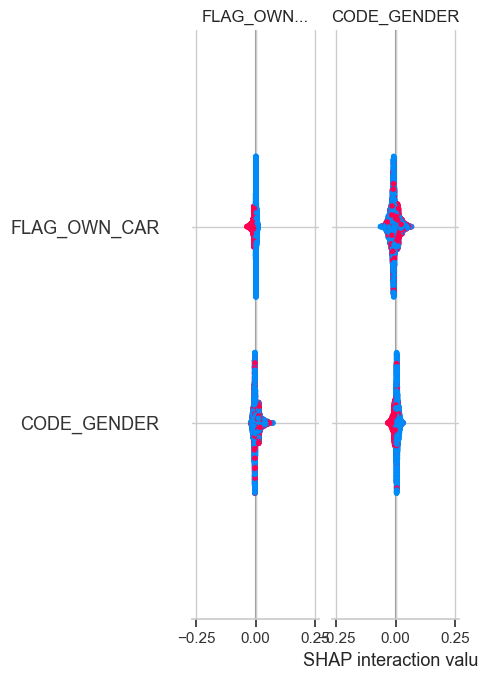

In [27]:
# Global feature importance (mean absolute SHAP value per feature)
shap.summary_plot(sv_high_risk, X_test, plot_type='bar', show=True)


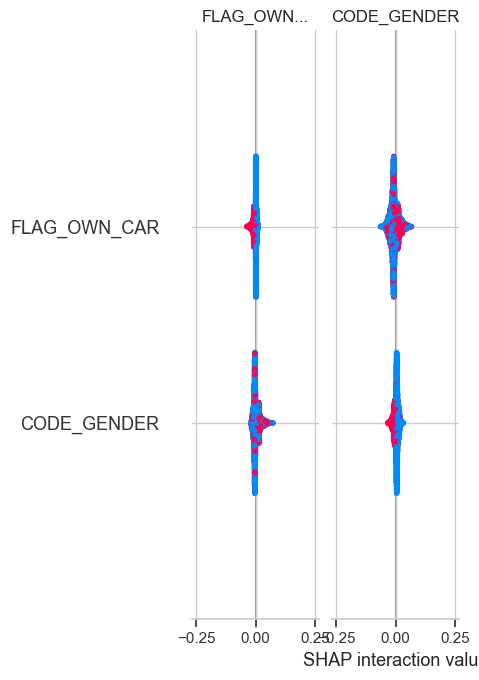

In [28]:
# Beeswarm plot: shows both importance AND directionality (does a high value push risk up or down?)
shap.summary_plot(sv_high_risk, X_test, show=True)


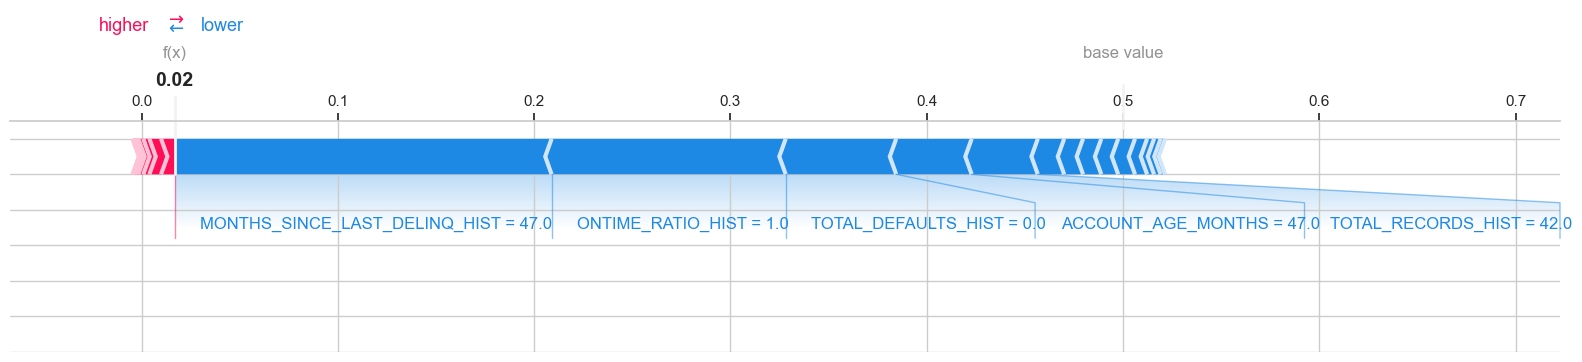

In [40]:
# Extract features as a 1D numpy array
feature_values = sample.iloc[0].values

# Extract ONLY the SHAP values for class 1 (High Risk) for this specific sample
# If sv_high_risk is shaped (samples, features, classes):
shap_values_single = sv_high_risk[sample_idx, :, 1] 

# OR if sv_high_risk is a list of arrays (one per class):
# shap_values_single = sv_high_risk[1][sample_idx]

shap.force_plot(
    explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    shap_values_single,
    feature_values,
    feature_names=X_test.columns.tolist(),
    matplotlib=True,
)


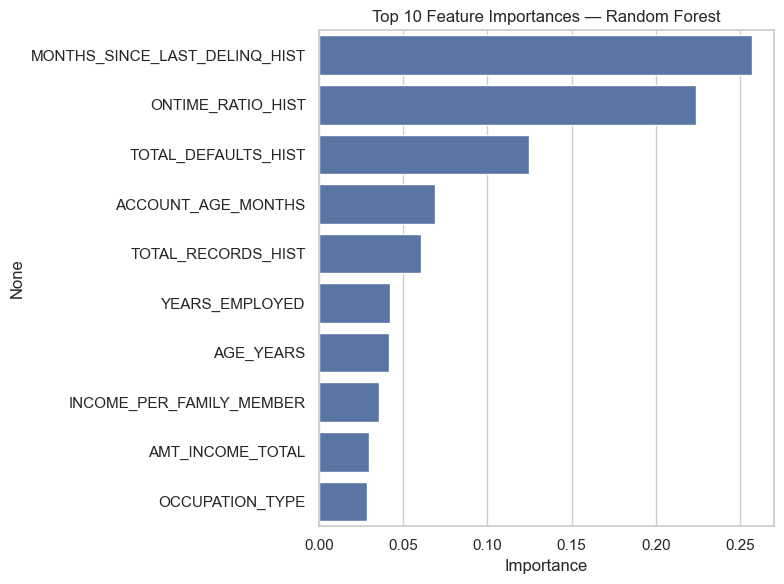

MONTHS_SINCE_LAST_DELINQ_HIST    0.257242
ONTIME_RATIO_HIST                0.223715
TOTAL_DEFAULTS_HIST              0.124998
ACCOUNT_AGE_MONTHS               0.068640
TOTAL_RECORDS_HIST               0.060428
dtype: float64


In [41]:
# Cross-check: Random Forest's built-in feature_importances_ (fast, model-native alternative to SHAP)
importances = pd.Series(best_model.feature_importances_, index=FEATURE_NAMES).sort_values(ascending=False)
plt.figure(figsize=(8, 6))
sns.barplot(x=importances.values[:10], y=importances.index[:10], color="#4C72B0")
plt.title('Top 10 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print(importances.head(5))


**Interpretation:** The top predictors are almost entirely **behavioral / credit-history features** (e.g., months since last delinquency, on-time payment ratio, historical default count, account age) rather than raw demographics. This matches real-world credit scoring: *how someone has actually managed credit* is a much stronger predictor of future risk than who they are demographically — which is also a fairer, more defensible basis for a lending decision than proxies like income alone.


## 10. Export Model

We save everything the Streamlit app (`app.py`) needs in a single pickle file, `best_model.pkl`:
- The trained best model
- The fitted `StandardScaler` (used only if the deployed model is Logistic Regression)
- The fitted `LabelEncoder`s for categorical columns
- The full ordered feature list the model expects
- The **top-5 most important features** (for the app's input form)
- Median/mode **default values** for every other feature (so the app only has to ask the user about the top 5)
- Feature importances and test-set metrics, for display in the app


In [42]:
# Median/mode defaults for every feature (used by the app to fill in features NOT collected from the user)
feature_defaults = {}
for col in FEATURE_NAMES:
    if col in fitted_encoders:
        feature_defaults[col] = model_source[col].mode().iloc[0]
    else:
        feature_defaults[col] = float(X[col].median())

top_5_features = importances.head(5).index.tolist()
print("Top 5 features for the Streamlit app:", top_5_features)

model_bundle = {
    'model': best_model,
    'model_name': BEST_MODEL_NAME,
    'scaler': scaler,
    'encoders': fitted_encoders,
    'feature_names': FEATURE_NAMES,
    'top_features': top_5_features,
    'feature_defaults': feature_defaults,
    'feature_importances': importances.to_dict(),
    'metrics': results[BEST_MODEL_NAME],
}

with open('best_model.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print("Saved best_model.pkl")


Top 5 features for the Streamlit app: ['MONTHS_SINCE_LAST_DELINQ_HIST', 'ONTIME_RATIO_HIST', 'TOTAL_DEFAULTS_HIST', 'ACCOUNT_AGE_MONTHS', 'TOTAL_RECORDS_HIST']
Saved best_model.pkl


In [43]:
# Quick reload sanity check
with open('best_model.pkl', 'rb') as f:
    reloaded = pickle.load(f)

sample_row = X_test.iloc[[0]]
print("Reloaded model prediction:", reloaded['model'].predict(sample_row))
print("Reloaded model probability:", reloaded['model'].predict_proba(sample_row))
print("Bundle keys:", list(reloaded.keys()))


Reloaded model prediction: [0]
Reloaded model probability: [[0.98307986 0.01692014]]
Bundle keys: ['model', 'model_name', 'scaler', 'encoders', 'feature_names', 'top_features', 'feature_defaults', 'feature_importances', 'metrics']


### Next step

Copy `best_model.pkl` into the same folder as `app.py`, then run:

```bash
pip install streamlit
streamlit run app.py
```

This launches the interactive creditworthiness prediction app, built around the **top 5 features** identified above.
